In [2]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import src.Filters as Filter
from utils.constants import BASELINE_CONFIG, VALIDATION_CSV
from utils.phase4 import apply_quality_filters
from utils.plot import plotTrainResults


In [3]:
baseline_train = BASELINE_CONFIG

PHASE3_DEDUP_CSV = Path("data/phase3/phase3_deduplicated_train.csv")
IMAGES_DIR = Path("data/phase2/frames")
PHASE4_DIR = Path("data/phase4")
PHASE4_FILTERED_CSV = PHASE4_DIR / "phase4_filtered_train.csv"

PHASE4_DIR.mkdir(parents=True, exist_ok=True)

phase3_deduplicated_df = pd.read_csv(PHASE3_DEDUP_CSV)
print(f"Phase 3 deduplicated rows: {len(phase3_deduplicated_df)}")
print("Histology frequency before quality filters:")
print(phase3_deduplicated_df["histology"].value_counts())


Phase 3 deduplicated rows: 7201
Histology frequency before quality filters:
histology
Adenoma                     2660
Sessile_serrated_adenoma    2330
Hyperplastic                1510
Adenocarcinoma               701
Name: count, dtype: int64


In [4]:
quality_params = Filter.FilterParams(
    darkness_threshold=60.0,
    uniformity_threshold=6.3,
    blur_threshold=25.0,
)

filter_specs = [
    {
        "filter": "darkness",
        "column": "brightness_v_mean",
        "selected_threshold": quality_params.darkness_threshold,
        "candidate_thresholds": [55.0, 60.0, 65.0],
        "keep_mask": lambda dataframe, threshold: dataframe["brightness_v_mean"] >= threshold,
    },
    {
        "filter": "uniformity",
        "column": "uniformity_entropy",
        "selected_threshold": quality_params.uniformity_threshold,
        "candidate_thresholds": [6.0, 6.3, 6.5],
        "keep_mask": lambda dataframe, threshold: dataframe["uniformity_entropy"] >= threshold,
    },
    {
        "filter": "blur",
        "column": "laplacian_variance",
        "selected_threshold": quality_params.blur_threshold,
        "candidate_thresholds": [25.0, 30.0, 35.0],
        "keep_mask": lambda dataframe, threshold: dataframe["laplacian_variance"] >= threshold,
    },
]


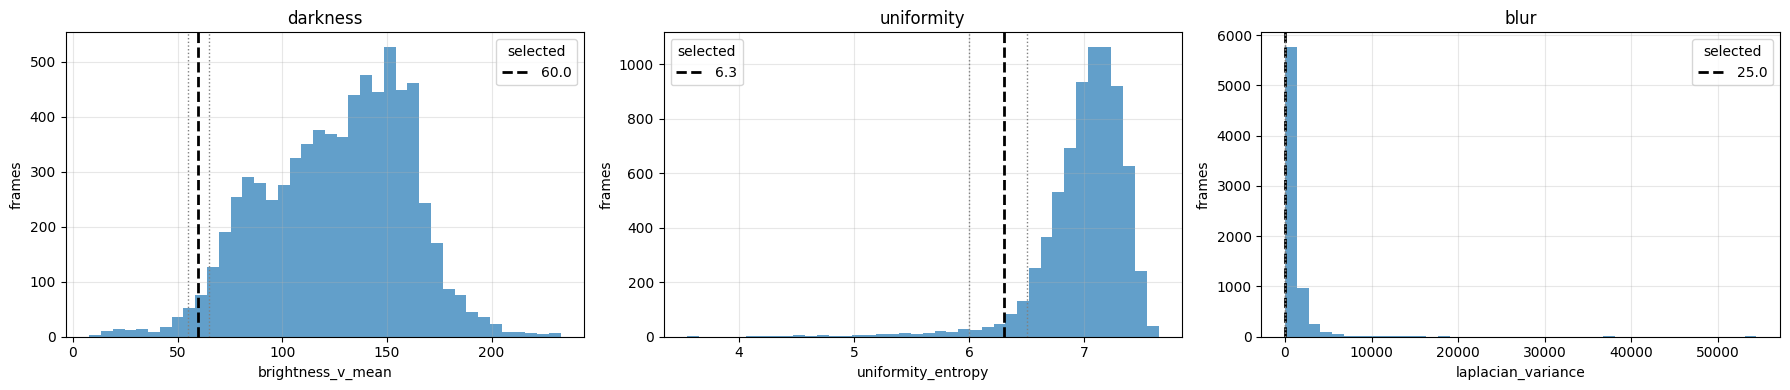

In [5]:
fig, axes = plt.subplots(1, len(filter_specs), figsize=(18, 4))

for axis, spec in zip(axes, filter_specs):
    values = phase3_deduplicated_df[spec["column"]].dropna()
    axis.hist(values, bins=40, alpha=0.7)

    for threshold in spec["candidate_thresholds"]:
        is_selected = threshold == spec["selected_threshold"]
        axis.axvline(
            threshold,
            linestyle="--" if is_selected else ":",
            linewidth=2.0 if is_selected else 1.0,
            color="black" if is_selected else "gray",
            label=f"{threshold}" if is_selected else None,
        )

    axis.set_title(spec["filter"])
    axis.set_xlabel(spec["column"])
    axis.set_ylabel("frames")
    axis.grid(True, alpha=0.3)
    axis.legend(title="selected")

plt.tight_layout()
plt.show()


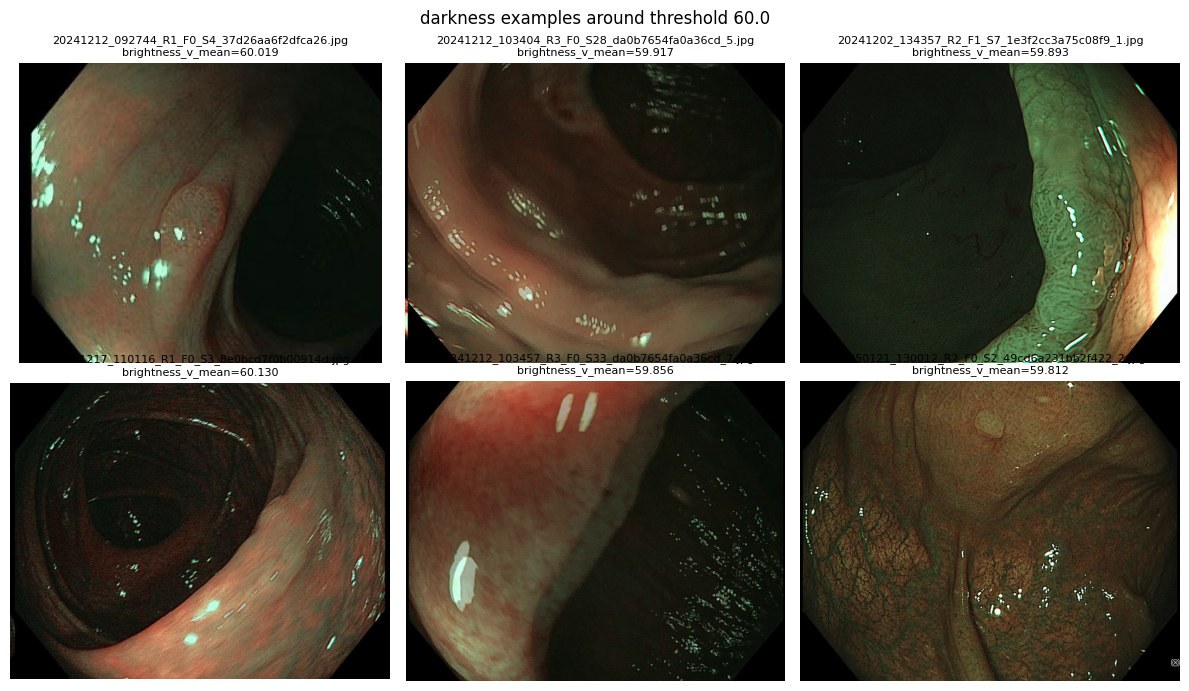

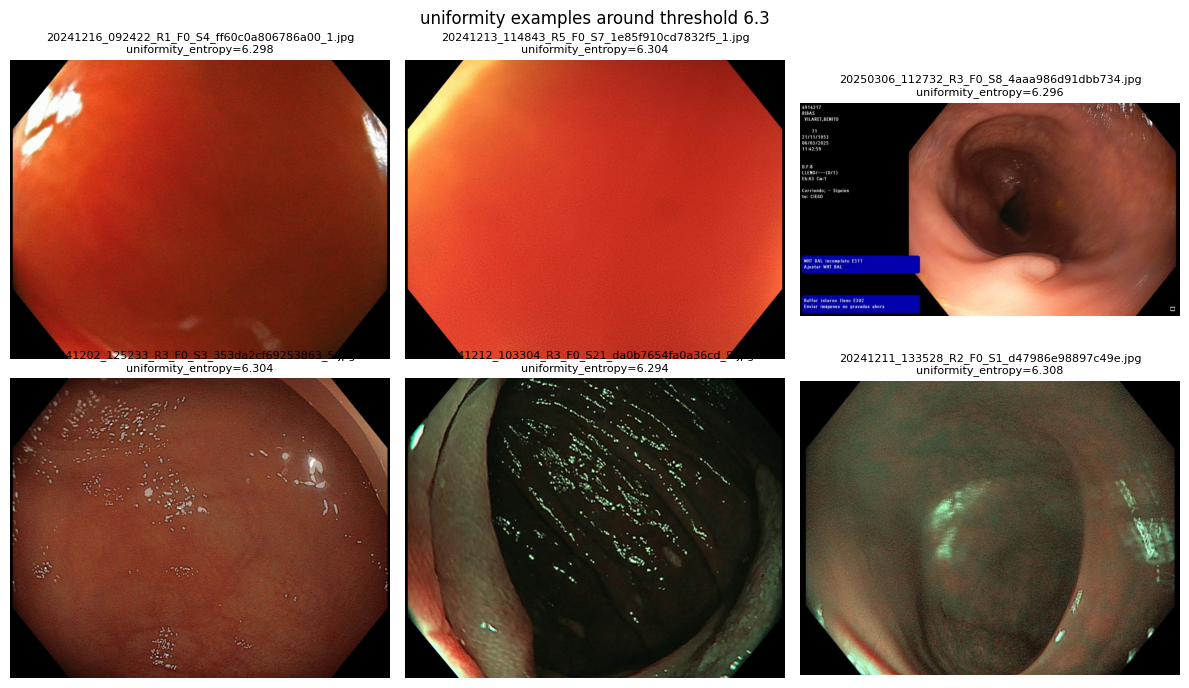

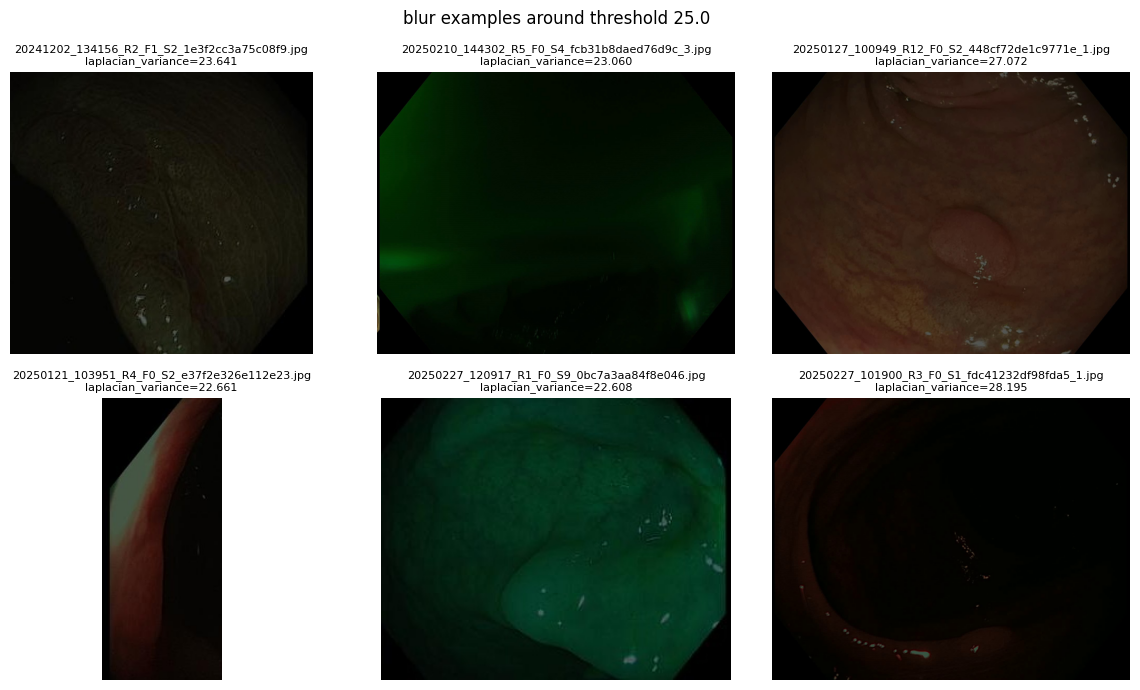

In [6]:
def show_quality_examples(
    dataframe: pd.DataFrame,
    column: str,
    threshold: float,
    images_dir: str | Path,
    title: str,
    n_examples: int = 6,
) -> None:
    examples_df = dataframe.copy()
    examples_df["distance_to_threshold"] = (examples_df[column] - threshold).abs()
    examples_df = examples_df.sort_values("distance_to_threshold").head(n_examples)

    if examples_df.empty:
        return

    n_cols = 3
    n_rows = int(np.ceil(len(examples_df) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3.5 * n_rows))
    axes = np.array(axes).reshape(-1)

    for axis, (_, row) in zip(axes, examples_df.iterrows()):
        image_path = Path(images_dir) / str(row["filename"])
        image = cv2.imread(str(image_path), cv2.IMREAD_COLOR)

        if image is not None and image.size > 0:
            axis.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

        axis.set_title(f"{row['filename']}\n{column}={row[column]:.3f}", fontsize=8)
        axis.axis("off")

    for axis in axes[len(examples_df):]:
        axis.axis("off")

    fig.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.show()


for spec in filter_specs:
    show_quality_examples(
        dataframe=phase3_deduplicated_df,
        column=spec["column"],
        threshold=spec["selected_threshold"],
        images_dir=IMAGES_DIR,
        title=f"{spec['filter']} examples around threshold {spec['selected_threshold']}",
    )


In [7]:
phase4_filtered_df = apply_quality_filters(
    params=quality_params,
    dataframe_or_csv=phase3_deduplicated_df,
    enabled_filters=(True, True, True),
    images_dir=IMAGES_DIR,
)
phase4_filtered_df.to_csv(PHASE4_FILTERED_CSV, index=False)

print(f"Phase 4 filtered CSV saved in: {PHASE4_FILTERED_CSV}")
print(f"Rows before quality filters: {len(phase3_deduplicated_df)}")
print(f"Rows after quality filters: {len(phase4_filtered_df)}")
print(f"Rows removed by quality filters: {len(phase3_deduplicated_df) - len(phase4_filtered_df)}")


Phase 4 filtered CSV saved in: data\phase4\phase4_filtered_train.csv
Rows before quality filters: 7201
Rows after quality filters: 6876
Rows removed by quality filters: 325


In [8]:
print("Histology frequency after phase 4 quality filters:")
print(phase4_filtered_df["histology"].value_counts())


Histology frequency after phase 4 quality filters:
histology
Adenoma                     2524
Sessile_serrated_adenoma    2257
Hyperplastic                1438
Adenocarcinoma               657
Name: count, dtype: int64


In [9]:
csv_relative_path = Path("phase4/phase4_filtered_train.csv")
image_relative_dir = Path("phase2/frames")
validation_csv_dir = VALIDATION_CSV
validation_img_dir = Path("unified_images")
results_dir = Path("phase4_experiment_fixed_val")

plotTrainResults(
    train_csv_dir=csv_relative_path,
    validation_csv_dir=validation_csv_dir,
    train_img_dir=image_relative_dir,
    validation_img_dir=validation_img_dir,
    results_dir=results_dir,
    train=baseline_train,
)


Hardware assigned for tensor computations: cuda
Training metadata: C:\Users\luis\Documents\TFG - Data-Centric AI\data\phase4\phase4_filtered_train.csv
Validation metadata: C:\Users\luis\Documents\TFG - Data-Centric AI\data\validation.csv
Train class distribution:
histology
Adenoma                     2524
Sessile_serrated_adenoma    2257
Hyperplastic                1438
Adenocarcinoma               657

Validation class distribution:
histology
Adenoma                     379
Sessile_serrated_adenoma    168
Hyperplastic                 80
Adenocarcinoma               20

Loss weights: {'Adenoma': 0.5185, 'Sessile_serrated_adenoma': 0.5798, 'Hyperplastic': 0.91, 'Adenocarcinoma': 1.9918}
Initiating training phase. Saving results to: C:\Users\luis\Documents\TFG - Data-Centric AI\results\phase4_experiment_fixed_val


Training Progress:   3%|▎         | 3/100 [10:01<5:25:03, 201.06s/epoch, Stage=head_only, Train Loss=0.6386, Val Loss=1.3323, Val F1=0.3675, LR=1.0e-03]        


Switching to full-network fine-tuning at epoch 4.


Training Progress:   6%|▌         | 6/100 [23:02<6:00:51, 230.34s/epoch, Stage=full_network, Train Loss=0.6548, Val Loss=1.3104, Val F1=0.3675, LR=1.0e-05/1.0e-04]


KeyboardInterrupt: 